# Week 4 - Task 2: Ensemble Learning — Random Forest vs XGBoost

**Goal:** Train Random Forest and XGBoost classifiers on the churn dataset, compare them against Week 4's single-model pipeline (Logistic Regression, Decision Tree), and compare feature importance behavior between the two ensemble methods.

**Dataset:** `data/telco_churn.csv` (same dataset used since Week 3, same restricted feature set as Week 4 for a valid apples-to-apples comparison).


In [2]:
# 1. Imports
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

from xgboost import XGBClassifier

# 2. Load dataset (same one used since Week 3)
df = pd.read_csv("../data/telco_churn.csv")
print(df.shape)
df.head()

(7043, 50)


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


## 2. Feature Set (same as Week 3/4 for valid comparison)

In [3]:
# Restrict to Week 3/4 feature set for valid comparison across all models
features = ['Tenure in Months', 'Monthly Charge', 'Contract', 'Payment Method', 'Internet Type', 'Total Charges']
target = 'Churn Label'

X = df[features].copy()
y = df[target].map({'Yes': 1, 'No': 0})

numerical_cols = ['Tenure in Months', 'Monthly Charge', 'Total Charges']
categorical_cols = ['Contract', 'Payment Method', 'Internet Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Preprocessing pipeline (identical to Week 4)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='No Internet Service')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print(preprocessor)

Train shape: (5634, 6)
Test shape: (1409, 6)
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Tenure in Months', 'Monthly Charge',
                                  'Total Charges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='No '
                                                                           'Internet '
                                                                           'Service',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Contract', 'Payment Method',
                                  'Internet Type']

## 3. Baseline Recall (Week 4 Pipeline Results)

For valid comparison, recalling Week 4's single-model pipeline results on this same feature set:

| Model | Accuracy |
|---|---|
| Logistic Regression | 80.13% (80.34% with engineered features) |
| Decision Tree | 74.24% (74.66% with engineered features) |

## 4. Random Forest Classifier

In [4]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest F1-score:", rf_f1)
print()
print(classification_report(y_test, rf_preds, target_names=['No Churn', 'Churn']))

Random Forest Accuracy: 0.7707594038325053
Random Forest F1-score: 0.5284671532846715

              precision    recall  f1-score   support

    No Churn       0.82      0.87      0.85      1035
       Churn       0.58      0.48      0.53       374

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409



## 5. XGBoost Classifier

In [5]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])

xgb_pipeline.fit(X_train, y_train)
xgb_preds = xgb_pipeline.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost F1-score:", xgb_f1)
print()
print(classification_report(y_test, xgb_preds, target_names=['No Churn', 'Churn']))

XGBoost Accuracy: 0.78708303761533
XGBoost F1-score: 0.5786516853932584

              precision    recall  f1-score   support

    No Churn       0.84      0.87      0.86      1035
       Churn       0.61      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



## 6. Feature Importance Comparison (Random Forest vs XGBoost)

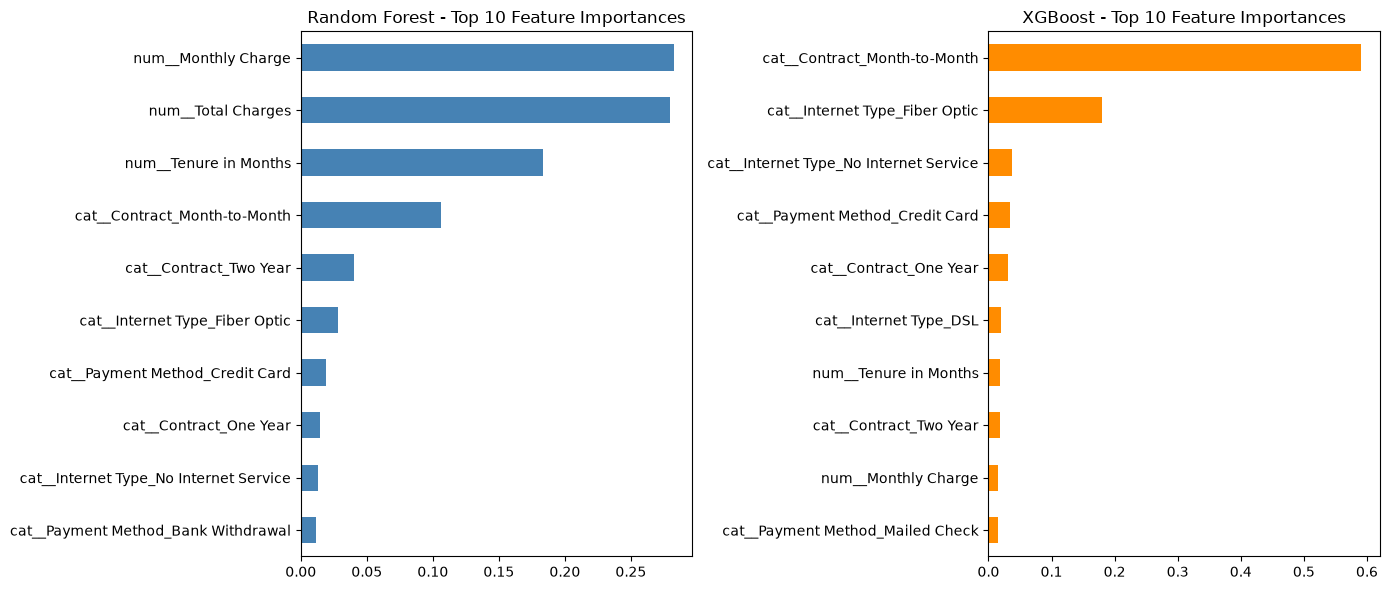

Random Forest Top 5:
 num__Monthly Charge             0.282438
num__Total Charges              0.279902
num__Tenure in Months           0.183782
cat__Contract_Month-to-Month    0.106330
cat__Contract_Two Year          0.040169
dtype: float64

XGBoost Top 5:
 cat__Contract_Month-to-Month              0.591116
cat__Internet Type_Fiber Optic            0.179683
cat__Internet Type_No Internet Service    0.037889
cat__Payment Method_Credit Card           0.033423
cat__Contract_One Year                    0.030291
dtype: float32


In [6]:
# Get feature names after one-hot encoding
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

rf_importances = rf_pipeline.named_steps['classifier'].feature_importances_
xgb_importances = xgb_pipeline.named_steps['classifier'].feature_importances_

rf_series = pd.Series(rf_importances, index=feature_names).sort_values(ascending=False)
xgb_series = pd.Series(xgb_importances, index=feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_series.head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest - Top 10 Feature Importances')
axes[0].invert_yaxis()

xgb_series.head(10).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('XGBoost - Top 10 Feature Importances')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Random Forest Top 5:\n", rf_series.head(5))
print("\nXGBoost Top 5:\n", xgb_series.head(5))

## 7. How Random Forest and XGBoost Differ in Combining Models

Random Forest builds many decision trees independently and in parallel (bagging), each on a random subset of data and features, then averages their votes — this is why importance is spread fairly evenly across `Monthly Charge`, `Total Charges`, and `Tenure in Months`, since no single tree dominates the final prediction. XGBoost builds trees sequentially (boosting), where each new tree is trained specifically to correct the errors of the previous ones, causing the model to concentrate heavily on whichever feature gives the biggest error-reduction early on — here, `Contract_Month-to-Month` alone accounts for 59% of XGBoost's importance versus Random Forest's more distributed ~28% max. In this run, that sequential error-correction gave XGBoost a slight edge over Random Forest (78.71% vs 77.08% accuracy), though both ensembles outperformed the single Decision Tree (74.24%) while Logistic Regression still led overall (80.13%) on this small, largely linear feature set.

## 8. Final Model Comparison

| Model | Accuracy | F1-score (Churn) |
|---|---|---|
| Logistic Regression | 80.13% | 0.64 |
| XGBoost | 78.71% | 0.58 |
| Random Forest | 77.08% | 0.53 |
| Decision Tree | 74.24% | 0.54 |

Both ensemble methods outperformed the single Decision Tree, confirming that combining trees (whether by bagging or boosting) reduces variance versus a single unpruned tree. XGBoost edged out Random Forest here, though Logistic Regression remained the strongest model overall — a reminder that ensembles aren't automatically better than a well-suited simpler model, especially on small, mostly-linear feature sets like this one.

## 9. Conclusion

Trained and compared Random Forest and XGBoost classifiers against Week 4's Logistic Regression and Decision Tree pipeline results on the same churn dataset and feature set. Both ensemble methods beat the single Decision Tree (RF: 77.08%, XGBoost: 78.71%, vs Decision Tree: 74.24%), with XGBoost's sequential boosting giving it a slight edge over Random Forest's parallel bagging. Logistic Regression remained the top performer overall (80.13%). Feature importance plots showed Random Forest spreading importance across numerical features (Monthly Charge, Total Charges, Tenure), while XGBoost concentrated heavily on a single categorical split (Contract_Month-to-Month at 59%), reflecting the structural difference between bagging and boosting.

## 10. Save Best Ensemble Model

In [7]:
# XGBoost had the best accuracy among ensemble methods
joblib.dump(xgb_pipeline, 'churn_pipeline_xgboost.joblib')

# Verify by reloading and predicting
loaded_model = joblib.load('churn_pipeline_xgboost.joblib')
reload_preds = loaded_model.predict(X_test)

print("Reloaded model accuracy:", accuracy_score(y_test, reload_preds))
print("Matches original XGBoost predictions:", (reload_preds == xgb_preds).all())

Reloaded model accuracy: 0.78708303761533
Matches original XGBoost predictions: True
